# Домашнее задание 1. Постановка и классификация задач, МНК, LP

**Выдано:** 9 сентября 2026. **Срок сдачи:** 23 сентября 2026 (до начала занятия). **Максимум:** 10 баллов (+1 бонус).

**Как сдавать.** Заполните этот ноутбук (ответы на теоретические вопросы — в markdown-ячейках, формулы в $\LaTeX$; код — в code-ячейках), выполните целиком (`Kernel → Restart Kernel and Run All Cells`) и сдайте через pull request: файл `submissions/hw01/<фамилия>.ipynb`, инструкция — [`CONTRIBUTING.md`](../CONTRIBUTING.md). Задачи можно обсуждать, но текст и код пишутся самостоятельно.

**Материал:** лекция 1 ([конспект](../lectures/lecture01/lecture01.md), [демо](../lectures/lecture01/demo01.ipynb)). Ничего сверх лекции не требуется.

Запуск: `uv sync` в корне репозитория, затем `uv run jupyter lab`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog, minimize

rng = np.random.default_rng(2026)   # не меняйте seed: данные должны совпадать у всех

## Задача 1. Классификация (4 балла)

Для каждой задачи (а)–(г) запишите её в стандартной форме

$$\min_x f(x) \quad\text{при}\quad g(x) = 0,\; h(x) \ge 0,$$

явно указав, что такое $x$ (и его размерность), $f$, $g$, $h$. Затем определите класс: LP / QP / QCQP / NLP; с ограничениями или без; выпуклая или нет (обоснуйте там, где это очевидно). По 1 баллу за пункт.

**(а)** Найти точку прямой $\{x \in \mathbb{R}^3 : x_1 + x_2 + x_3 = 1,\; x_1 - x_3 = 0\}$, ближайшую к точке $(1, 2, 3)$. *Дополнительно:* найдите эту точку (руками или численно).

**(б)** Диета: $n$ продуктов с ценами $c_j$; $m$ питательных веществ, продукт $j$ содержит $A_{ij}$ единиц вещества $i$. Купить продукты минимальной стоимости так, чтобы каждого вещества было не меньше $b_i$.

**(в)** Найти вписанный в единичный круг прямоугольник наибольшей площади (стороны параллельны осям).

**(г)** Подогнать модель $\varphi(t; x) = x_1 \sin(x_2 t + x_3)$ к измерениям $(t_i, y_i)$, $i = 1, \dots, N$, по критерию суммы квадратов невязок.

**(д, бонус +1)** $\min_{x \in \mathbb{R}^n} \max_i |a_i^\top x - b_i|$ (подгонка в чебышёвской норме). Переформулируйте как гладкую задачу с одной дополнительной переменной, по образцу переформулировки из раздела 8 лекции. Какой это класс?

**(а)**

**Ответ.**

**Стандартная форма.** Переменная — сама искомая точка, $x \in \mathbb{R}^3$ ($n = 3$). Минимизируем квадрат расстояния до $p = (1, 2, 3)^\top$ (минимум расстояния и минимум его квадрата достигаются в одной точке, но квадрат гладкий):

$$\min_{x \in \mathbb{R}^3} f(x) = \tfrac12\|x - p\|^2 \quad\text{при}\quad g(x) = \begin{pmatrix} x_1 + x_2 + x_3 - 1 \\ x_1 - x_3 \end{pmatrix} = 0,$$

$f : \mathbb{R}^3 \to \mathbb{R}$, $g : \mathbb{R}^3 \to \mathbb{R}^2$; ограничений-неравенств нет ($h$ отсутствует, их число равно нулю).

**Класс.** Раскрывая скобки, $f(x) = \tfrac12 x^\top I x - p^\top x + \tfrac12\|p\|^2$, то есть $Q = I$. Целевая функция квадратична, ограничения линейны — это **QP** (и одновременно линейный МНК: $f = \tfrac12\|Ix - p\|^2$). Задача **с ограничениями-равенствами**, **выпуклая**: $Q = I \succ 0$, а допустимое множество — прямая, то есть аффинное (значит выпуклое) множество. Более того, $f$ строго выпукла, поэтому решение существует и единственно.

**Решение.** Два независимых равенства в $\mathbb{R}^3$ задают прямую. Параметризуем её: из второго равенства $x_1 = x_3 = t$, тогда из первого $x_2 = 1 - 2t$, то есть $x(t) = (0,1,0)^\top + t\,(1,-2,1)^\top$. Подставляем:

$$\|x(t) - p\|^2 = (t-1)^2 + (2t+1)^2 + (t-3)^2 = 6t^2 - 4t + 11 .$$

Это парабола ветвями вверх, её минимум в $t^\ast = \tfrac{4}{12} = \tfrac13$. Значит

$$\boxed{\,x^\ast = \left(\tfrac13, \tfrac13, \tfrac13\right)^\top}, \qquad \|x^\ast - p\| = \sqrt{31/3} \approx 3.2146 .$$

Проверка геометрическим условием: вектор ошибки $x^\ast - p = (-\tfrac23, -\tfrac53, -\tfrac83)^\top$ должен быть ортогонален направлению прямой $(1,-2,1)^\top$: $-\tfrac23 + \tfrac{10}{3} - \tfrac83 = 0$. ✓

In [2]:
# Проверка 1(а): решение в явном виде и численно (rng здесь не используется)
p = np.array([1.0, 2.0, 3.0])
A_eq = np.array([[1.0, 1.0, 1.0],
                 [1.0, 0.0, -1.0]])
b_eq = np.array([1.0, 0.0])

# аналитический ответ
x_exact = np.array([1/3, 1/3, 1/3])

# численно: минимизация 0.5*||x - p||^2 при A_eq x = b_eq
res_a = minimize(lambda x: 0.5 * np.sum((x - p) ** 2), x0=np.zeros(3),
                 jac=lambda x: x - p,
                 constraints=[{"type": "eq",
                               "fun": lambda x: A_eq @ x - b_eq,
                               "jac": lambda x: A_eq}])

print("аналитически:", x_exact, " расстояние =", np.linalg.norm(x_exact - p))
print("численно:    ", res_a.x, " расстояние =", np.linalg.norm(res_a.x - p))
print("невязка равенств:", A_eq @ res_a.x - b_eq)
print("sqrt(31/3) =", np.sqrt(31 / 3))

аналитически: [0.33333333 0.33333333 0.33333333]  расстояние = 3.2145502536643185
численно:     [0.33333333 0.33333333 0.33333333]  расстояние = 3.2145502536643185
невязка равенств: [0.00000000e+00 5.55111512e-17]
sqrt(31/3) = 3.2145502536643185


**(б)**

**Ответ.**

**Стандартная форма.** Переменная $x \in \mathbb{R}^n$, $x_j$ — купленное количество продукта $j$ ($n$ = число продуктов). Данные: $c \in \mathbb{R}^n$ (цены), $A \in \mathbb{R}^{m \times n}$ (содержание вещества $i$ в продукте $j$), $b \in \mathbb{R}^m$ (нормы потребления).

$$\min_{x \in \mathbb{R}^n} f(x) = c^\top x \quad\text{при}\quad h(x) = \begin{pmatrix} Ax - b \\ x \end{pmatrix} \ge 0 .$$

Здесь $f : \mathbb{R}^n \to \mathbb{R}$ линейна; ограничений-равенств нет ($g$ отсутствует); $h : \mathbb{R}^n \to \mathbb{R}^{m+n}$ линейна. Условие $x \ge 0$ в словесной постановке не записано, но необходимо: отрицательное количество продукта купить нельзя. Это часть моделирования, и без него задача обычно не ограничена снизу.

**Класс.** Линейная цель и линейные неравенства — **LP**, задача **с ограничениями**, **выпуклая** (LP выпукла всегда: $c^\top x$ линейна, значит выпукла, а $\Omega$ — пересечение полупространств, то есть выпуклый многогранник).

Решение конкретного экземпляра — задача 2(б).

**(в)**

**Ответ.**

**Стандартная форма.** Прямоугольник со сторонами, параллельными осям, вписанный в единичный круг, симметричен относительно обеих осей (иначе его можно расширить, оставшись внутри круга). Поэтому он задаётся вершиной в первом квадранте $x = (x_1, x_2)^\top \in \mathbb{R}^2$ ($n = 2$): стороны равны $2x_1$ и $2x_2$, площадь $S = 4x_1x_2$, а «вписанность» означает, что вершина лежит на окружности.

$$\min_{x \in \mathbb{R}^2} f(x) = -4x_1x_2 \quad\text{при}\quad g(x) = x_1^2 + x_2^2 - 1 = 0, \quad h(x) = \begin{pmatrix} x_1 \\ x_2 \end{pmatrix} \ge 0 .$$

Максимизация площади записана как минимизация $-S$; $g : \mathbb{R}^2 \to \mathbb{R}$, $h : \mathbb{R}^2 \to \mathbb{R}^2$.

**Класс.** Целевая функция квадратична: $f(x) = \tfrac12 x^\top Q x$ с $Q = \begin{pmatrix} 0 & -4 \\ -4 & 0\end{pmatrix}$; ограничение-равенство тоже квадратично. Это **QCQP**, задача **с ограничениями**, **невыпуклая** — по двум независимым причинам:

1. Собственные числа $Q$ равны $\pm 4$, то есть $Q$ знаконеопределена, и $f$ невыпукла.
2. Нелинейное равенство $x_1^2 + x_2^2 = 1$ задаёт дугу окружности — невыпуклое множество: середина отрезка между $(1,0)$ и $(0,1)$ равна $(0.5, 0.5)$ и на окружность не попадает.

Ограничение можно ослабить до $x_1^2 + x_2^2 \le 1$ (вершина внутри круга). Допустимое множество станет выпуклым — четвертью круга, а решение не изменится: увеличение любой координаты увеличивает площадь, поэтому оптимум всё равно на границе. Но целевая функция остаётся невыпуклой, так что задача выпуклой не становится.

**Решение.** Положим $x_1 = \cos\theta$, $x_2 = \sin\theta$, $\theta \in [0, \pi/2]$. Тогда $S = 4\cos\theta\sin\theta = 2\sin 2\theta \le 2$, и равенство достигается при $2\theta = \pi/2$, то есть $\theta = \pi/4$:

$$\boxed{\,x^\ast = \left(\tfrac{1}{\sqrt2}, \tfrac{1}{\sqrt2}\right)^\top}, \qquad \text{квадрат со стороной } \sqrt2, \qquad S_{\max} = 2 .$$

Оба ограничения-неравенства в решении **неактивны** ($x_i^\ast = 1/\sqrt2 > 0$), активно только равенство.

**(г)**

**Ответ.**

**Стандартная форма.** Переменная — вектор параметров модели $x = (x_1, x_2, x_3)^\top \in \mathbb{R}^3$ ($n = 3$): амплитуда, частота, фаза. Измерения $(t_i, y_i)$ — это данные, а не переменные. Невязки $r_i(x) = x_1\sin(x_2 t_i + x_3) - y_i$, $r : \mathbb{R}^3 \to \mathbb{R}^N$:

$$\min_{x \in \mathbb{R}^3} f(x) = \tfrac12 \sum_{i=1}^{N} \big(x_1\sin(x_2 t_i + x_3) - y_i\big)^2 = \tfrac12\|r(x)\|^2 .$$

Ограничений нет: $g$ и $h$ отсутствуют, $\Omega = \mathbb{R}^3$.

**Класс.** Модель нелинейна по параметрам ($x_2$ и $x_3$ стоят внутри синуса), поэтому $f$ — не квадратичная функция: это **NLP**, **безусловная**, **невыпуклая**. Структурно — задача **нелинейного МНК** (сумма квадратов), и эта структура позволяет применять Гаусс–Ньютона (лекция 5), но класс задачи не меняет.

**Почему невыпуклая.** Достаточно заметить симметрию модели: $x_1\sin(x_2t + x_3) = (-x_1)\sin(x_2 t + x_3 + \pi)$, то есть $f(x_1, x_2, x_3) = f(-x_1, x_2, x_3 + \pi)$, и так же $f$ периодична по $x_3$ с периодом $2\pi$. Значит у задачи есть несколько **изолированных** точек с одним и тем же минимальным значением. У выпуклой функции множество минимумов выпукло, поэтому две различные изолированные точки минимума с равным значением невозможны. Практическое следствие: результат работы метода зависит от начального приближения (как в примере 7.4 лекции), и частоту $x_2$ нужно инициализировать осмысленно.

Для сравнения: если бы частота и фаза были известны, а подбиралась только амплитуда $x_1$, модель стала бы линейной по параметру и задача превратилась бы в выпуклую безусловную QP (линейный МНК, раздел 7.1 лекции).

**(д, бонус)**

**Ответ.**

Исходная задача $\min_{x} \max_i |a_i^\top x - b_i|$ негладкая: и модуль, и максимум изломаны. Приём из раздела 8 лекции: ввести **одну** вспомогательную переменную $s \in \mathbb{R}$ — верхнюю границу для всех невязок сразу (в $\ell_1$-примере лекции переменных было $m$, потому что там стояла сумма; здесь максимум, и достаточно одной общей границы).

$$\min_{(x,s) \in \mathbb{R}^{n+1}} s \quad\text{при}\quad -s \le a_i^\top x - b_i \le s, \quad i = 1, \dots, m .$$

**Стандартная форма.** Переменная $z = (x, s) \in \mathbb{R}^{n+1}$, целевая $f(z) = e_{n+1}^\top z = s$ (линейна); равенств нет; неравенства

$$h(z) = \begin{pmatrix} s - (a_i^\top x - b_i) \\ s + (a_i^\top x - b_i) \end{pmatrix}_{i=1,\dots,m} \ge 0, \qquad h : \mathbb{R}^{n+1} \to \mathbb{R}^{2m},$$

тоже линейны.

**Эквивалентность.** При фиксированном $x$ пара неравенств равносильна $s \ge |a_i^\top x - b_i|$ для каждого $i$, то есть $s \ge \max_i |a_i^\top x - b_i|$. Минимизация по $s$ прижимает его к нижней границе, поэтому в оптимуме $s^\ast = \max_i|a_i^\top x^\ast - b_i|$ — значение исходной целевой функции, и ничего не потеряно.

**Класс.** Линейная цель, линейные неравенства — **LP**, задача **с ограничениями**, **выпуклая** и **гладкая**. Негладкая задача заменой переменных превратилась в тот класс, для которого есть самые надёжные методы. Активными в решении оказываются ограничения, отвечающие точкам с максимальной по модулю невязкой, — если $s^\ast > 0$, их не меньше $n+1$ (решение LP достигается в вершине, а вершина в $\mathbb{R}^{n+1}$ требует $n+1$ активных ограничений) — дискретный аналог чебышёвского альтернанса.

## Задача 2. Практика (6 баллов)

**(а) Линейный МНК и переобучение (3 балла).** Ниже сгенерированы обучающая и тестовая выборки: $y = \sin(2\pi t) + \varepsilon$, $\varepsilon \sim \mathcal{N}(0, 0.1^2)$. Для каждой степени $d = 1, \dots, 15$ подгоните полином $\varphi(t; x) = x_0 + x_1 t + \dots + x_d t^d$ методом наименьших квадратов (`numpy.linalg.lstsq`; матрицу $A$ удобно строить через `np.vander(t, d + 1, increasing=True)`). Постройте график зависимости среднеквадратичной ошибки на обучающей и на тестовой выборках от $d$ (ось $y$ — логарифмическая). Объясните поведение обеих кривых в двух-трёх предложениях: почему одна монотонна, а другая нет?

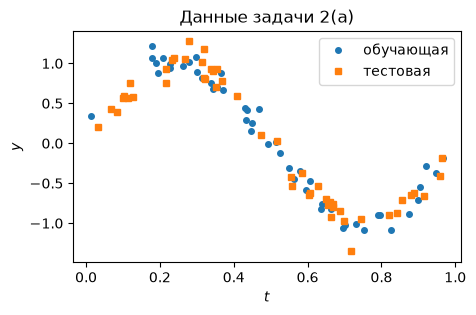

In [3]:
N = 50
t_train = np.sort(rng.uniform(0, 1, N))
y_train = np.sin(2 * np.pi * t_train) + 0.1 * rng.standard_normal(N)
t_test = np.sort(rng.uniform(0, 1, N))
y_test = np.sin(2 * np.pi * t_test) + 0.1 * rng.standard_normal(N)

plt.figure(figsize=(5, 3))
plt.plot(t_train, y_train, "o", ms=4, label="обучающая")
plt.plot(t_test, y_test, "s", ms=4, label="тестовая")
plt.legend(); plt.xlabel("$t$"); plt.ylabel("$y$"); plt.title("Данные задачи 2(а)")
plt.show()

  d    MSE train     MSE test     max|x_j|
  1   1.5147e-01   2.2580e-01     2.69e+00
  2   1.3912e-01   2.6208e-01     4.69e+00
  3   1.0690e-02   3.1528e-02     3.30e+01
  4   9.9329e-03   3.1880e-02     2.45e+01
  5   9.4644e-03   2.5973e-02     6.33e+01
  6   9.0300e-03   3.4745e-02     3.03e+02
  7   9.0000e-03   3.9952e-02     1.02e+03
  8   8.8965e-03   6.5674e-02     1.07e+04
  9   8.8873e-03   8.3233e-02     3.21e+04
 10   8.0379e-03   8.9422e-01     1.58e+06
 11   7.9879e-03   1.6789e+00     4.20e+06
 12   7.9811e-03   2.4098e+00     1.16e+07
 13   6.8568e-03   8.5707e+01     8.41e+08
 14   6.4610e-03   1.2501e+00     2.64e+09
 15   6.0771e-03   3.3650e+02     2.34e+10

MSE train монотонно не возрастает: True
минимум ошибки на тесте: d = 5, MSE = 2.5973e-02
дисперсия шума sigma^2 = 0.010000000000000002


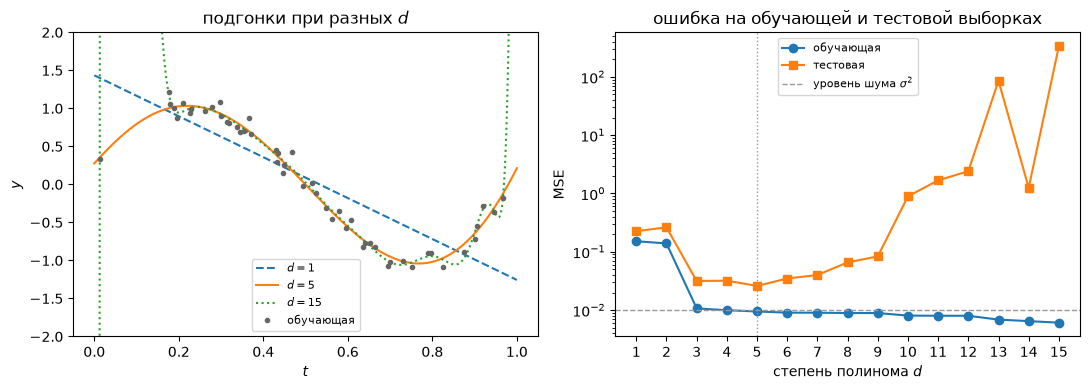

In [4]:
degrees = np.arange(1, 16)
mse_train = np.zeros(len(degrees))
mse_test = np.zeros(len(degrees))
coef_max = np.zeros(len(degrees))

for k, d in enumerate(degrees):
    A_tr = np.vander(t_train, d + 1, increasing=True)   # A[i, j] = t_i^j
    x_hat, *_ = np.linalg.lstsq(A_tr, y_train, rcond=None)   # min ||A x - y||^2 через QR/SVD
    A_te = np.vander(t_test, d + 1, increasing=True)
    mse_train[k] = np.mean((A_tr @ x_hat - y_train) ** 2)
    mse_test[k] = np.mean((A_te @ x_hat - y_test) ** 2)
    coef_max[k] = np.abs(x_hat).max()

d_best = degrees[np.argmin(mse_test)]
print(f"{'d':>3} {'MSE train':>12} {'MSE test':>12} {'max|x_j|':>12}")
for k, d in enumerate(degrees):
    print(f"{d:>3} {mse_train[k]:>12.4e} {mse_test[k]:>12.4e} {coef_max[k]:>12.2e}")
print(f"\nMSE train монотонно не возрастает: {np.all(np.diff(mse_train) <= 0)}")
print(f"минимум ошибки на тесте: d = {d_best}, MSE = {mse_test.min():.4e}")
print(f"дисперсия шума sigma^2 = {0.1**2}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

grid = np.linspace(0, 1, 400)
for d, style in [(1, "--"), (d_best, "-"), (15, ":")]:
    x_hat, *_ = np.linalg.lstsq(np.vander(t_train, d + 1, increasing=True), y_train, rcond=None)
    ax[0].plot(grid, np.vander(grid, d + 1, increasing=True) @ x_hat, style, label=f"$d = {d}$")
ax[0].plot(t_train, y_train, "o", ms=3, color="0.4", label="обучающая")
ax[0].set_ylim(-2, 2); ax[0].set_xlabel("$t$"); ax[0].set_ylabel("$y$")
ax[0].set_title("подгонки при разных $d$"); ax[0].legend(fontsize=8)

ax[1].semilogy(degrees, mse_train, "o-", label="обучающая")
ax[1].semilogy(degrees, mse_test, "s-", label="тестовая")
ax[1].axhline(0.1 ** 2, color="0.6", ls="--", lw=1, label=r"уровень шума $\sigma^2$")
ax[1].axvline(d_best, color="0.6", ls=":", lw=1)
ax[1].set_xlabel("степень полинома $d$"); ax[1].set_ylabel("MSE")
ax[1].set_title("ошибка на обучающей и тестовой выборках"); ax[1].legend(fontsize=8)
ax[1].set_xticks(degrees)

plt.tight_layout(); plt.show()

**Ответ.**

**Ошибка на обучающей выборке монотонно убывает**: полиномы степени $\le d$ образуют линейное подпространство, вложенное в полиномы степени $\le d+1$. МНК берёт минимум квадратичной невязки по всему подпространству, а минимум по большему множеству не может быть больше минимума по меньшему. Значит $\mathrm{MSE}_{\text{train}}(d+1) \le \mathrm{MSE}_{\text{train}}(d)$ при любых данных. Численно она падает с $1.5\cdot10^{-1}$ при $d=1$ до $6.1\cdot10^{-3}$ при $d = 15$ — и уходит **ниже уровня шума** $\sigma^2 = 10^{-2}$: лишние степени свободы тратятся на подгонку под конкретную реализацию $\varepsilon$.

**Ошибка на тестовой выборке немонотонна**, потому что она измеряется на точках, которых модель не видела, и никакого аргумента о вложенности для неё нет. Сначала она падает ($2.3\cdot10^{-1}$ при $d=1$ → $2.6\cdot10^{-2}$ при $d = 5$): прямая и парабола слишком бедны, чтобы описать $\sin 2\pi t$, и ошибка определяется **смещением**. Резкий провал между $d = 2$ и $d = 3$ (с $2.6\cdot10^{-1}$ до $3.2\cdot10^{-2}$) объясняется формой кривой: у $\sin 2\pi t$ на $[0,1]$ два экстремума, а полином с двумя внутренними экстремумами имеет степень не ниже третьей. Минимум достигается при $d = 5$ — там, где выигрыш от новых степеней перестаёт перекрывать подгонку под шум. Дальше ошибка растёт, и на $d \ge 10$ — на порядки ($9\cdot10^{-1}$ при $d=10$, $3\cdot10^{2}$ при $d = 15$): модель повторяет шум обучающей выборки, между узлами начинает сильно осциллировать, коэффициенты раздуваются с единиц до $2\cdot10^{10}$ — растёт **дисперсия** оценки. Это переобучение и классический компромисс смещения и дисперсии.

Рваность правого конца тестовой кривой (например, $d = 13$ хуже, чем $d = 14$) — уже не статистика, а численная обусловленность: число обусловленности матрицы Вандермонда растёт с $5$ при $d=1$ до $3\cdot10^{12}$ при $d=15$, и при таких коэффициентах значение полинома считается со значительной потерей точности. Практический вывод: в этом режиме результат зависит не только от модели, но и от алгоритма её подгонки.

**(б) LP: диета (3 балла).** Решите задачу диеты из 1(б) с помощью `scipy.optimize.linprog` для данных ниже (4 продукта, 3 вещества). Выведите оптимальное $x$ и стоимость. Определите, какие из ограничений $Ax \ge b$ и $x \ge 0$ **активны** в решении (невязка равна нулю с точностью $10^{-9}$). Затем увеличьте требование по первому веществу на единицу ($b_1 \to b_1 + 1$), решите заново и сравните: как изменились решение и стоимость? Изменился ли набор активных ограничений?

Подсказка: `linprog` минимизирует $c^\top x$ при $A_{ub} x \le b_{ub}$, поэтому ограничение $Ax \ge b$ нужно переписать со знаком минус; `bounds=(0, None)` задаёт $x \ge 0$.

In [5]:
c = np.array([2.0, 3.0, 1.5, 4.0])                # цены продуктов
A = np.array([[1.0, 2.0, 0.0, 3.0],
              [2.0, 1.0, 1.0, 1.0],
              [0.0, 3.0, 2.0, 2.0]])                 # содержание вещества i в продукте j
b = np.array([10.0, 8.0, 12.0])                     # минимальные требования

In [6]:
TOL = 1e-9

def solve_diet(b_vec, title):
    res = linprog(c, A_ub=-A, b_ub=-b_vec, bounds=(0, None))   # Ax >= b  <=>  -Ax <= -b
    assert res.status == 0, res.message
    x = res.x
    slack_nutr = A @ x - b_vec          # невязка ограничений Ax >= b
    act_nutr = np.where(np.abs(slack_nutr) < TOL)[0]
    act_nonneg = np.where(np.abs(x) < TOL)[0]

    print(f"=== {title} (b = {b_vec}) ===")
    print(f"  x*        = {np.round(x, 6)}")
    print(f"  стоимость = {res.fun:.6f}")
    print(f"  Ax - b    = {np.round(slack_nutr, 12)}")
    print(f"  активные Ax >= b : вещества {[int(i) for i in act_nutr + 1]}")
    print(f"  активные x >= 0  : продукты {[int(j) for j in act_nonneg + 1]}")
    n_active = len(act_nutr) + len(act_nonneg)
    G = np.vstack([A[act_nutr], np.eye(len(c))[act_nonneg]])
    print(f"  всего активных: {n_active} при n = {len(c)} переменных, "
          f"ранг матрицы активных ограничений = {np.linalg.matrix_rank(G)}")
    return res, {int(i) for i in act_nutr + 1} | {-int(j) for j in act_nonneg + 1}

res1, act1 = solve_diet(b, "исходная задача")
print()
b_new = b + np.array([1.0, 0.0, 0.0])
res2, act2 = solve_diet(b_new, "b1 увеличено на 1")

print(f"\nизменение x*        : {np.round(res2.x - res1.x, 6)}")
print(f"изменение стоимости : {res2.fun - res1.fun:.6f}  (= 10/9 = {10/9:.6f})")
print(f"набор активных ограничений изменился: {act1 != act2}")
print(f"  было : {sorted(act1)}")
print(f"  стало: {sorted(act2)}   (отрицательные индексы = ограничения x_j >= 0)")

=== исходная задача (b = [10.  8. 12.]) ===
  x*        = [ 2.  4. -0.  0.]
  стоимость = 16.000000
  Ax - b    = [0. 0. 0.]
  активные Ax >= b : вещества [1, 2, 3]
  активные x >= 0  : продукты [3, 4]
  всего активных: 5 при n = 4 переменных, ранг матрицы активных ограничений = 4

=== b1 увеличено на 1 (b = [11.  8. 12.]) ===
  x*        = [1.888889 3.555556 0.       0.666667]
  стоимость = 17.111111
  Ax - b    = [0. 0. 0.]
  активные Ax >= b : вещества [1, 2, 3]
  активные x >= 0  : продукты [3]
  всего активных: 4 при n = 4 переменных, ранг матрицы активных ограничений = 4

изменение x*        : [-0.111111 -0.444444  0.        0.666667]
изменение стоимости : 1.111111  (= 10/9 = 1.111111)
набор активных ограничений изменился: True
  было : [-4, -3, 1, 2, 3]
  стало: [-3, 1, 2, 3]   (отрицательные индексы = ограничения x_j >= 0)


**Ответ.**

**Исходная задача.** $x^\ast = (2,\; 4,\; 0,\; 0)^\top$, стоимость $c^\top x^\ast = 16$. Покупаются только продукты 1 и 2.

**Активные ограничения.** Все три ограничения по веществам активны: $Ax^\ast = (10, 8, 12)^\top = b$ точно, невязки нулевые — каждого вещества куплено ровно по норме, без запаса. Кроме того активны два ограничения неотрицательности: $x_3 = 0$ и $x_4 = 0$. Итого **пять** активных ограничений при $n = 4$ переменных.

Пять активных ограничений на четыре переменные — это больше, чем нужно для определения вершины (ранг матрицы активных ограничений равен 4). Такая вершина называется **вырожденной**: одно активное ограничение «лишнее». Это не ошибка счёта, а свойство данных, и дальше оно себя проявит.

**После $b_1 \to 11$.** $x^\ast = \left(\tfrac{17}{9},\; \tfrac{32}{9},\; 0,\; \tfrac23\right)^\top \approx (1.889,\; 3.556,\; 0,\; 0.667)$, стоимость $\tfrac{154}{9} \approx 17.111$.

- **Решение изменилось качественно:** в рацион вошёл продукт 4, которого раньше не было, а закупки продуктов 1 и 2 сократились. Продукт 4 самый дорогой ($c_4 = 4$), но, кроме продуктов 1 и 2, он единственный источник первого вещества ($A_{14} = 3$, тогда как $A_{13} = 0$).
- **Стоимость выросла на** $\tfrac{10}{9} \approx 1.111$.
- **Набор активных ограничений изменился.** все три ограничения $Ax \ge b$ по-прежнему активны, $x_3 \ge 0$ по-прежнему активно, а $x_4 \ge 0$ стало **неактивным**. Активных ограничений теперь четыре — вершина перестала быть вырожденной.

Стоимость выросла ровно на $10/9$, хотя если уменьшить $b_1$ на единицу, она упадёт лишь на $5/9$ (решение тогда $(\tfrac{17}{9}, \tfrac{32}{9}, \tfrac23, 0)$ — в рацион входит дешёвый продукт 3). То есть у теневой цены первого вещества левая и правая производные разные, $5/9$ слева и $10/9$ справа. Точка $b_1 = 10$ — это излом функции оптимального значения $V(b_1)$, и именно ему отвечает вырожденность вершины. При $b_1 < 10$ выгодно сократить продукты 1 и 2, а возникающий дефицит второго и третьего веществ добрать дешёвым продуктом 3 — первого вещества он не содержит вовсе ($A_{13} = 0$), зато стоит всего $1.5$. При $b_1 > 10$ дополнительное первое вещество брать больше не у кого, кроме продукта 4 ($A_{14} = 3$), а он стоит $4$. Ровно при $b_1 = 10$ и продукт 3, и продукт 4 равны нулю — это точка смены базиса. Поэтому теневую цену, которую вернул бы солвер в исходной точке, нельзя без оговорок использовать для прогноза «что будет, если норму поднять»: она верна только с одной стороны.